In [1]:
# Install the package in development mode if needed
# !pip install -e '.[dev]'

import asyncio
import os
import re
import copy
import sys
import logging
from pathlib import Path
import json
from fs import open_fs
from napistu import utils
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("napistu")

NAPISTU_DATA_DIR = "/tmp/napistu_data"
LOCAL_DATA_DIR = "/Users/sean/Desktop/GITHUB/napistu/dev/napistu_data/test_pathway"


/Users/sean/Desktop/GITHUB/napistu/dev/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore


In [2]:
from napistu.rpy2 import callr
from napistu.rpy2 import rids

from napistu.ingestion import hpa
from napistu.ingestion import gtex
from napistu.context import discretize
from napistu.ontologies import dogma
from napistu.ontologies import mygene
from napistu.matching import mount
from napistu.context import filtering
from napistu.ontologies.genodexito import Genodexito
from napistu.constants import ONTOLOGIES
from napistu.constants import RESOLVE_MATCHES_AGGREGATORS

def compare_zfpkm_implementations(fpkm_data):

    conversion, default_converter, importr = callr.get_rpy2_core_modules()
    zFPKM_R = importr("zFPKM")
    
    py_zFPKM_fits = discretize.zfpkm(fpkm_data)

    r_zFPKM_fits = (
        callr.r_dataframe_to_pandas(
            zFPKM_R.zFPKM(
                callr.pandas_to_r_dataframe(
                    fpkm_data.reset_index(drop=True)
                )
            )
        )
    )

    py_subset = py_zFPKM_fits.values.flatten()
    r_subset = r_zFPKM_fits.values.flatten()

    # Create scatterplot
    plt.figure(figsize=(8, 6))
    plt.scatter(py_subset, r_subset, alpha=0.6, s=20)

    # Add diagonal line for perfect agreement
    min_val = min(py_subset.min(), r_subset.min())
    max_val = max(py_subset.max(), r_subset.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='Perfect agreement')
    # add x and y axis labels
    plt.xlabel('zFPKM (Python)')
    plt.ylabel('zFPKM (R)')
    plt.show()

In [3]:
napistu_r = callr.get_napistu_r()


INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /opt/homebrew/Cellar/r/4.5.0_1/lib/R
INFO:rpy2.situation:R library path: :/opt/homebrew/lib
INFO:rpy2.situation:LD_LIBRARY_PATH: :/opt/homebrew/lib
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
/Users/sean/Desktop/GITHUB/napistu/dev/.venv/lib/python3.11/site-packages/rpy2/rinterface/__init__.py:1185: UserWarning: Environment variable "PWD" redefined by R and overriding existing variable. Current: "/", R: "/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/random_things"
  warnings.warn(
/Users/sean/Desktop/GITHUB/napistu/dev/.venv/lib/python3.11/site-packages/rpy2/rinterface/__init__.py:1185: UserWarning: Environment variable "XPC_SERVICE_NAME" redefined by R and overriding existing variable. Current: "application.com.todesktop.230313mzl4w4u92.7974323.7974329", R: "0"
  warnings.warn(
/Users/sean/Desktop/GITHUB/napistu/dev/.venv/lib/python3.11/site-packag

In [4]:
from napistu.gcs import downloads

sbml_dfs_path = downloads.load_public_napistu_asset("test_pathway", NAPISTU_DATA_DIR, subasset = "sbml_dfs", overwrite = False)
# sbml_dfs_path = os.path.join(LOCAL_DATA_DIR, "test_pathway", "sbml_dfs.pkl")
sbml_dfs = utils.load_pickle(sbml_dfs_path)

## ID mapping



In [5]:
# add ensembl gene ids so that we can test the HPA & GTEx data mounting to species_data
sbml_dfs_expanded = copy.deepcopy(sbml_dfs)
Genodexito(
    species="Homo sapiens",
    preferred_method="bioconductor"
).expand_sbml_dfs_ids(sbml_dfs_expanded, ontologies={ONTOLOGIES.ENSEMBL_GENE, ONTOLOGIES.UNIPROT, ONTOLOGIES.NCBI_ENTREZ_GENE})

sbml_dfs_expanded.get_identifiers("species").value_counts("ontology")

INFO:napistu.rpy2.rids:Creating mapping tables from entrez genes to/from ncbi_entrez_gene, ensembl_gene, uniprot


ontology
reactome            942
uniprot             134
ensembl_gene        130
ncbi_entrez_gene    123
chebi                86
pubmed               28
Name: count, dtype: int64

In [6]:
r_mappings = rids.create_bioconductor_mapping_tables(
    mappings={ONTOLOGIES.ENSEMBL_GENE, ONTOLOGIES.UNIPROT, ONTOLOGIES.NCBI_ENTREZ_GENE}, 
    species="Homo sapiens", 
    r_paths=None
)


INFO:napistu.rpy2.rids:Creating mapping tables from entrez genes to/from ncbi_entrez_gene, ensembl_gene, uniprot


In [7]:
python_mappings = mygene.create_python_mapping_tables(
    mappings={ONTOLOGIES.ENSEMBL_GENE, ONTOLOGIES.UNIPROT, ONTOLOGIES.NCBI_ENTREZ_GENE}, 
    species="Homo sapiens"
)


INFO:napistu.ontologies.mygene:Creating mapping tables from entrez genes to/from ncbi_entrez_gene, ensembl_gene, uniprot
INFO:napistu.ontologies.mygene:Fetching genome-wide gene data from MyGene...
INFO:httpx:HTTP Request: GET https://mygene.info/v3/query/?species=9606&fields=ensembl.gene%2Centrezgene%2Cuniprot.Swiss-Prot&fetch_all=true&q=type_of_gene%3Aprotein-coding "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://mygene.info/v3/query/?species=9606&fields=ensembl.gene%2Centrezgene%2Cuniprot.Swiss-Prot&scroll_id=FGluY2x1ZGVfY29udGV4dF91dWlkDXF1ZXJ5QW5kRmV0Y2gBFlNNQTZQalMzVF91TElYXzZmSGtOSUEAAAAAGHtRYRZ1aXJzb1FZNlRkeTlqdEZHYjE3WHJB "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://mygene.info/v3/query/?species=9606&fields=ensembl.gene%2Centrezgene%2Cuniprot.Swiss-Prot&scroll_id=FGluY2x1ZGVfY29udGV4dF91dWlkDXF1ZXJ5QW5kRmV0Y2gBFlNNQTZQalMzVF91TElYXzZmSGtOSUEAAAAAGHtRYRZ1aXJzb1FZNlRkeTlqdEZHYjE3WHJB "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://mygene.info/v3/query/?sp

In [8]:
dogmatic_sbml_dfs = dogma.create_dogmatic_sbml_dfs(
    species="Homo sapiens",
    preferred_method="bioconductor", # or python
    allow_fallback=True,
)


INFO:napistu.rpy2.rids:Creating mapping tables from entrez genes to/from uniprot, gene_name, ensembl_gene, ensembl_transcript, ensembl_protein, ncbi_entrez_gene, symbol
INFO:napistu.utils:creating an edgelist linking index levels ncbi_entrez_gene and linking it to levels defined by ontology, identifier
INFO:napistu.ontologies.dogma:Creating inputs for sbml_dfs_from_edgelist()


## Contextualization

In [10]:
HPA_TARGET_URI = "/tmp/napistu_data/hpa_data.tsv"

# hpa.download_hpa_data(target_uri = HPA_TARGET_URI)
hpa_data = hpa.load_and_clean_hpa_data(HPA_TARGET_URI)

cooccurrence_filtered_sbml_dfs = copy.deepcopy(sbml_dfs_expanded)
mount.bind_wide_results(
    sbml_dfs = cooccurrence_filtered_sbml_dfs,
    results_df = hpa_data.reset_index(drop=False),
    results_name = "hpa",
    ontologies = {ONTOLOGIES.ENSEMBL_GENE},
    numeric_agg = RESOLVE_MATCHES_AGGREGATORS.MAX
)

filtering.filter_reactions_with_disconnected_cspecies(
    cooccurrence_filtered_sbml_dfs,
    "hpa",
    inplace = False
)


INFO:napistu.ingestion.hpa:Start downloading proteinatlas https://www.proteinatlas.org/download/tsv/subcellular_location.tsv.zip to /tmp/napistu_data/hpa_data.tsv
INFO:napistu.ingestion.hpa:Loading Human Protein Atlas subcellular localization data
INFO:napistu.ingestion.hpa:Created localization matrix with shape 13534 genes x 49 compartments
INFO:napistu.sbml_dfs_utils:Running in non-dogmatic mode - genes, transcripts, and proteins will be merged if possible.
INFO:napistu.matching.species:Using columns as results: ['Plasma membrane (GO:0005886)', 'Basal body (GO:0036064)', 'Vesicles (GO:0043231)', 'Centrosome (GO:0005813)', 'Microtubule ends (GO:1990752)', 'Nucleoplasm (GO:0005654)', 'Nucleoli fibrillar center (GO:0001650)', 'Aggresome (GO:0016235)', 'Cytokinetic bridge (GO:0045171)', 'Intermediate filaments (GO:0045111)', 'Rods & Rings ()', 'Calyx (GO:0120238)', 'Cytoplasmic bodies (GO:0036464)', 'Endosomes (GO:0005768)', 'Centriolar satellite (GO:0034451)', 'Flagellar centriole (GO:0

In [11]:
GTEX_TARGET_URI = "/tmp/napistu_data/gtex_data.tsv"

# gtex.download_gtex_rnaseq(target_uri = GTEX_TARGET_URI)
gtex_data = gtex.load_and_clean_gtex_data(GTEX_TARGET_URI)
gtex_zfpkm_df, gtex_is_expressed_df = discretize.discretize_expression_data(gtex_data)

gtex_filtered_sbml_dfs = copy.deepcopy(sbml_dfs_expanded)
mount.bind_wide_results(
    sbml_dfs = gtex_filtered_sbml_dfs,
    results_df = gtex_is_expressed_df.drop(columns = [ONTOLOGIES.ENSEMBL_GENE_VERSION, ONTOLOGIES.SYMBOL]),
    results_name = "gtex",
    ontologies = {ONTOLOGIES.ENSEMBL_GENE},
    numeric_agg = RESOLVE_MATCHES_AGGREGATORS.MAX
)
filtering.filter_species_by_attribute(
    gtex_filtered_sbml_dfs,
    "gtex",
    attribute_name="Liver",
    # remove entries which are NOT in the liver
    attribute_value=0,
    inplace = False
)


INFO:napistu.ingestion.gtex:Loading GTEx tissue specific expression data
INFO:napistu.context.discretize:Removed 36163 genes whose expression across all samples was below 50.
INFO:napistu.context.discretize:Discretizing expression data...
INFO:napistu.context.discretize:Expression fraction: 0.914
INFO:napistu.sbml_dfs_utils:Running in non-dogmatic mode - genes, transcripts, and proteins will be merged if possible.
INFO:napistu.matching.species:Using columns as results: ['Colon - Sigmoid', 'Brain - Cortex', 'Brain - Substantia nigra', 'Cells - Cultured fibroblasts', 'Stomach', 'Kidney - Cortex', 'Brain - Hypothalamus', 'Brain - Caudate (basal ganglia)', 'Adipose - Subcutaneous', 'Muscle - Skeletal', 'Brain - Anterior cingulate cortex (BA24)', 'Nerve - Tibial', 'Spleen', 'Liver', 'Thyroid', 'Cells - EBV-transformed lymphocytes', 'Esophagus - Gastroesophageal Junction', 'Esophagus - Mucosa', 'Colon - Transverse', 'Kidney - Medulla', 'Cervix - Endocervix', 'Brain - Cerebellar Hemisphere', 

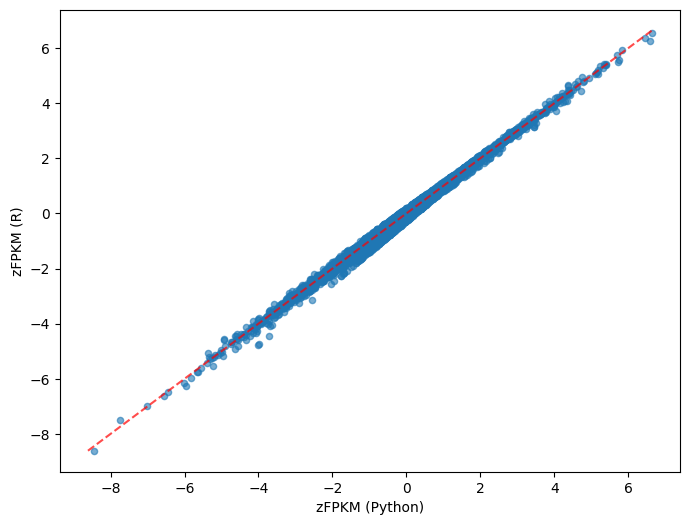

In [12]:
zFPKM_test_data = discretize.generate_simple_test_data()

compare_zfpkm_implementations(zFPKM_test_data)
